# 🩹 Wound Classification - V4 (Optimized)

## What's Different in V4:
- ✅ **Shorter Phase 2** (stop before overfitting starts)
- ✅ **Gradual Unfreezing** (unfreeze layers slowly, not all at once)
- ✅ **Mixup Augmentation** (blend images for better generalization)
- ✅ **Stronger Weight Decay** (prevents overfitting)
- ✅ **Cosine Annealing with Warm Restarts** (better LR schedule)
- ✅ **Best of V2 + V3** combined

**Target: 80-85% accuracy with <5% overfitting gap**

---

## Cell 1: Imports

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import copy
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
from torchvision import transforms, datasets, models

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   Running on CPU")

✅ Using device: cpu
   Running on CPU


## Cell 2: Configuration ⚙️

### 👇 V4 OPTIMIZED SETTINGS 👇

In [2]:
# =============================================================================
# ⚙️ V4 OPTIMIZED CONFIGURATION
# =============================================================================

# 👇👇👇 THREE-PHASE TRAINING 👇👇👇
# Phase 1: Frozen backbone - train classifier
PHASE1_EPOCHS = 10
PHASE1_LR = 5e-4

# Phase 2: Unfreeze top 3 blocks - gradual fine-tuning
PHASE2_EPOCHS = 15
PHASE2_LR = 1e-4

# Phase 3: Full fine-tuning with very low LR
PHASE3_EPOCHS = 15
PHASE3_LR = 1e-5

# Total = 40 epochs

BATCH_SIZE = 32
DROPOUT_RATE = 0.45        # Between V2 (0.5) and V3 (0.4)
WEIGHT_DECAY = 5e-4        # Stronger regularization
LABEL_SMOOTHING = 0.1
PATIENCE = 8               # Stricter early stopping
USE_MIXUP = True           # Mixup augmentation
MIXUP_ALPHA = 0.2          # Mixup strength
# 👆👆👆 THREE-PHASE TRAINING 👆👆👆

# Paths
CROPPED_DATA_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\cropped_classification_data"
MODEL_SAVE_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models"

IMAGE_SIZE = 224
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print("="*60)
print("⚙️ V4 CONFIGURATION (Three-Phase + Mixup)")
print("="*60)
print(f"   Phase 1 (Frozen):      {PHASE1_EPOCHS} epochs @ LR={PHASE1_LR}")
print(f"   Phase 2 (Top layers):  {PHASE2_EPOCHS} epochs @ LR={PHASE2_LR}")
print(f"   Phase 3 (Full tune):   {PHASE3_EPOCHS} epochs @ LR={PHASE3_LR}")
print(f"   Total Epochs:          {PHASE1_EPOCHS + PHASE2_EPOCHS + PHASE3_EPOCHS}")
print(f"   Dropout:               {DROPOUT_RATE}")
print(f"   Weight Decay:          {WEIGHT_DECAY}")
print(f"   Mixup:                 {USE_MIXUP} (alpha={MIXUP_ALPHA})")
print(f"   Early Stopping:        {PATIENCE} epochs")
print("="*60)

⚙️ V4 CONFIGURATION (Three-Phase + Mixup)
   Phase 1 (Frozen):      10 epochs @ LR=0.0005
   Phase 2 (Top layers):  15 epochs @ LR=0.0001
   Phase 3 (Full tune):   15 epochs @ LR=1e-05
   Total Epochs:          40
   Dropout:               0.45
   Weight Decay:          0.0005
   Mixup:                 True (alpha=0.2)
   Early Stopping:        8 epochs


## Cell 3: Data Transforms

In [3]:
def get_train_transforms():
    """Balanced augmentation."""
    return transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(degrees=25),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.1),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
    ])

def get_val_transforms():
    """Validation/Test transforms."""
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

print("✅ Transforms defined!")

✅ Transforms defined!


## Cell 4: Mixup Augmentation

In [4]:
def mixup_data(x, y, alpha=0.2):
    """
    Mixup: Blend two images and their labels.
    This helps the model generalize better and reduces overfitting.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calculate loss for mixup samples."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("✅ Mixup augmentation defined!")

✅ Mixup augmentation defined!


## Cell 5: Load Datasets

In [5]:
print("📂 Loading datasets...\n")

train_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Train'),
    transform=get_train_transforms()
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Valid'),
    transform=get_val_transforms()
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'test'),
    transform=get_val_transforms()
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("="*60)
print("📊 DATASET SUMMARY")
print("="*60)
print(f"   Classes:     {train_dataset.classes}")
print(f"   Training:    {len(train_dataset):,} images")
print(f"   Validation:  {len(val_dataset):,} images")
print(f"   Test:        {len(test_dataset):,} images")
print("="*60)

📂 Loading datasets...

📊 DATASET SUMMARY
   Classes:     ['infected', 'non-infected']
   Training:    700 images
   Validation:  170 images
   Test:        152 images


## Cell 6: Model Architecture (V4)

In [6]:
class WoundClassifierV4(nn.Module):
    """
    EfficientNet-B0 with gradual unfreezing support.
    """
    def __init__(self, num_classes=2, dropout_rate=0.45):
        super().__init__()
        
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = models.efficientnet_b0(weights=weights)
        
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        
        # Classifier with batch norm and dropout
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate * 0.5),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
    
    def freeze_all_backbone(self):
        """Freeze entire backbone."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("   🔒 All backbone layers FROZEN")
    
    def unfreeze_top_blocks(self, num_blocks=3):
        """Unfreeze only top N blocks."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.features[-num_blocks:].parameters():
            param.requires_grad = True
        print(f"   🔓 Top {num_blocks} blocks UNFROZEN")
    
    def unfreeze_all_backbone(self):
        """Unfreeze entire backbone."""
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("   🔓 All backbone layers UNFROZEN")
    
    def get_trainable_params(self):
        """Get number of trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Create model
print("🏗️ Creating WoundClassifierV4...")
model = WoundClassifierV4(num_classes=2, dropout_rate=DROPOUT_RATE)
model = model.to(DEVICE)
model.freeze_all_backbone()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = model.get_trainable_params()

print(f"\n✅ Model created!")
print(f"   Total params:     {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")

🏗️ Creating WoundClassifierV4...
   🔒 All backbone layers FROZEN

✅ Model created!
   Total params:     4,352,702
   Trainable params: 345,154


## Cell 7: Training Functions

In [7]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0
        return self.early_stop
    
    def reset(self):
        self.counter = 0
        self.early_stop = False


def train_one_epoch(model, train_loader, criterion, optimizer, device, use_mixup=True, mixup_alpha=0.2):
    """Train for one epoch with optional mixup."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Apply mixup with 50% probability
        if use_mixup and random.random() > 0.5:
            images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            
            # For accuracy, use the dominant label
            _, predicted = outputs.max(1)
            if lam > 0.5:
                correct += predicted.eq(labels_a).sum().item()
            else:
                correct += predicted.eq(labels_b).sum().item()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total += labels.size(0)
        total_loss += loss.item()
        
        if (batch_idx + 1) % 25 == 0:
            print(f"      Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")
    
    return total_loss / len(train_loader), 100. * correct / total


def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            total_loss += loss.item()
    
    return total_loss / len(val_loader), 100. * correct / total

print("✅ Training functions defined!")

✅ Training functions defined!


## Cell 8: Three-Phase Training

In [8]:
def train_three_phase(model, train_loader, val_loader, save_path):
    """
    Three-phase training for optimal results:
    Phase 1: Frozen backbone
    Phase 2: Top 3 blocks unfrozen
    Phase 3: Full fine-tuning
    """
    
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    early_stopping = EarlyStopping(patience=PATIENCE)
    
    best_acc = 0.0
    best_model_state = None
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'phase': []}
    
    total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS + PHASE3_EPOCHS
    current_epoch = 0
    
    # =================================================================
    # PHASE 1: Frozen backbone
    # =================================================================
    print(f"\n{'='*60}")
    print(f"🚀 PHASE 1: Training Classifier Only")
    print(f"   Epochs: {PHASE1_EPOCHS} | LR: {PHASE1_LR}")
    print(f"{'='*60}")
    
    model.freeze_all_backbone()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS, eta_min=PHASE1_LR/10)
    
    for epoch in range(PHASE1_EPOCHS):
        current_epoch += 1
        print(f"\n📍 Epoch {current_epoch}/{total_epochs} [Phase 1]")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, USE_MIXUP, MIXUP_ALPHA)
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['phase'].append(1)
        
        gap = train_acc - val_acc
        gap_icon = "🟢" if gap < 5 else "🟡" if gap < 10 else "🔴"
        
        print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print(f"   Gap:   {gap:.1f}% {gap_icon}")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"   ✅ New best: {val_acc:.2f}%")
    
    # =================================================================
    # PHASE 2: Top 3 blocks unfrozen
    # =================================================================
    print(f"\n{'='*60}")
    print(f"🚀 PHASE 2: Gradual Fine-tuning (Top 3 Blocks)")
    print(f"   Epochs: {PHASE2_EPOCHS} | LR: {PHASE2_LR}")
    print(f"{'='*60}")
    
    model.unfreeze_top_blocks(3)
    print(f"   Trainable params: {model.get_trainable_params():,}")
    
    optimizer = optim.AdamW([
        {'params': model.backbone.features[-3:].parameters(), 'lr': PHASE2_LR},
        {'params': model.classifier.parameters(), 'lr': PHASE2_LR * 5}
    ], weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS, eta_min=PHASE2_LR/10)
    
    early_stopping.reset()
    
    for epoch in range(PHASE2_EPOCHS):
        current_epoch += 1
        print(f"\n📍 Epoch {current_epoch}/{total_epochs} [Phase 2]")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, USE_MIXUP, MIXUP_ALPHA)
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['phase'].append(2)
        
        gap = train_acc - val_acc
        gap_icon = "🟢" if gap < 5 else "🟡" if gap < 10 else "🔴"
        
        print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print(f"   Gap:   {gap:.1f}% {gap_icon}")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save({'epoch': current_epoch, 'model_state_dict': best_model_state, 'val_acc': best_acc}, save_path)
            print(f"   ✅ New best: {val_acc:.2f}% (saved!)")
        
        if early_stopping(val_acc):
            print(f"\n⚠️ Early stopping in Phase 2")
            break
    
    # =================================================================
    # PHASE 3: Full fine-tuning (very low LR)
    # =================================================================
    if not early_stopping.early_stop:
        print(f"\n{'='*60}")
        print(f"🚀 PHASE 3: Full Fine-tuning")
        print(f"   Epochs: {PHASE3_EPOCHS} | LR: {PHASE3_LR}")
        print(f"{'='*60}")
        
        model.unfreeze_all_backbone()
        print(f"   Trainable params: {model.get_trainable_params():,}")
        
        optimizer = optim.AdamW([
            {'params': model.backbone.parameters(), 'lr': PHASE3_LR},
            {'params': model.classifier.parameters(), 'lr': PHASE3_LR * 10}
        ], weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-7)
        
        early_stopping.reset()
        
        for epoch in range(PHASE3_EPOCHS):
            current_epoch += 1
            print(f"\n📍 Epoch {current_epoch}/{total_epochs} [Phase 3]")
            
            # Less mixup in phase 3 for stability
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, USE_MIXUP, MIXUP_ALPHA * 0.5)
            val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
            scheduler.step()
            
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['phase'].append(3)
            
            gap = train_acc - val_acc
            gap_icon = "🟢" if gap < 5 else "🟡" if gap < 10 else "🔴"
            
            print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
            print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
            print(f"   Gap:   {gap:.1f}% {gap_icon}")
            
            if val_acc > best_acc:
                best_acc = val_acc
                best_model_state = copy.deepcopy(model.state_dict())
                torch.save({'epoch': current_epoch, 'model_state_dict': best_model_state, 'val_acc': best_acc}, save_path)
                print(f"   ✅ New best: {val_acc:.2f}% (saved!)")
            
            # Stop if overfitting starts (gap > 8%)
            if gap > 8:
                print(f"\n⚠️ Stopping: Overfitting detected (gap > 8%)")
                break
            
            if early_stopping(val_acc):
                print(f"\n⚠️ Early stopping in Phase 3")
                break
    
    # =================================================================
    # COMPLETE
    # =================================================================
    print(f"\n{'='*60}")
    print(f"🏁 TRAINING COMPLETE!")
    print(f"{'='*60}")
    print(f"   Epochs trained:  {len(history['train_loss'])}")
    print(f"   Best Val Acc:    {best_acc:.2f}%")
    print(f"   Model saved to:  {save_path}")
    
    model.load_state_dict(best_model_state)
    
    return history, best_acc

print("✅ Three-phase training function defined!")

✅ Three-phase training function defined!


---
# 🏃 Cell 9: START TRAINING!
---

In [9]:
model_save_path = os.path.join(MODEL_SAVE_DIR, 'classification_efficientnet_v4.pth')

history, best_accuracy = train_three_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=model_save_path
)

print(f"\n🏆 Best Validation Accuracy: {best_accuracy:.2f}%")


🚀 PHASE 1: Training Classifier Only
   Epochs: 10 | LR: 0.0005
   🔒 All backbone layers FROZEN

📍 Epoch 1/40 [Phase 1]
   Train: Loss=0.6946, Acc=58.78%
   Val:   Loss=0.6548, Acc=76.47%
   Gap:   -17.7% 🟢
   ✅ New best: 76.47%

📍 Epoch 2/40 [Phase 1]
   Train: Loss=0.5981, Acc=68.30%
   Val:   Loss=0.6194, Acc=76.47%
   Gap:   -8.2% 🟢

📍 Epoch 3/40 [Phase 1]
   Train: Loss=0.5784, Acc=73.66%
   Val:   Loss=0.6017, Acc=79.41%
   Gap:   -5.8% 🟢
   ✅ New best: 79.41%

📍 Epoch 4/40 [Phase 1]
   Train: Loss=0.6087, Acc=68.30%
   Val:   Loss=0.5887, Acc=75.29%
   Gap:   -7.0% 🟢

📍 Epoch 5/40 [Phase 1]
   Train: Loss=0.5784, Acc=72.92%
   Val:   Loss=0.6109, Acc=76.47%
   Gap:   -3.6% 🟢

📍 Epoch 6/40 [Phase 1]
   Train: Loss=0.5843, Acc=73.07%
   Val:   Loss=0.6122, Acc=75.88%
   Gap:   -2.8% 🟢

📍 Epoch 7/40 [Phase 1]
   Train: Loss=0.5395, Acc=75.60%
   Val:   Loss=0.6181, Acc=74.71%
   Gap:   0.9% 🟢

📍 Epoch 8/40 [Phase 1]
   Train: Loss=0.5645, Acc=73.51%
   Val:   Loss=0.6336, Acc=72.94

## Cell 10: Plot Training History

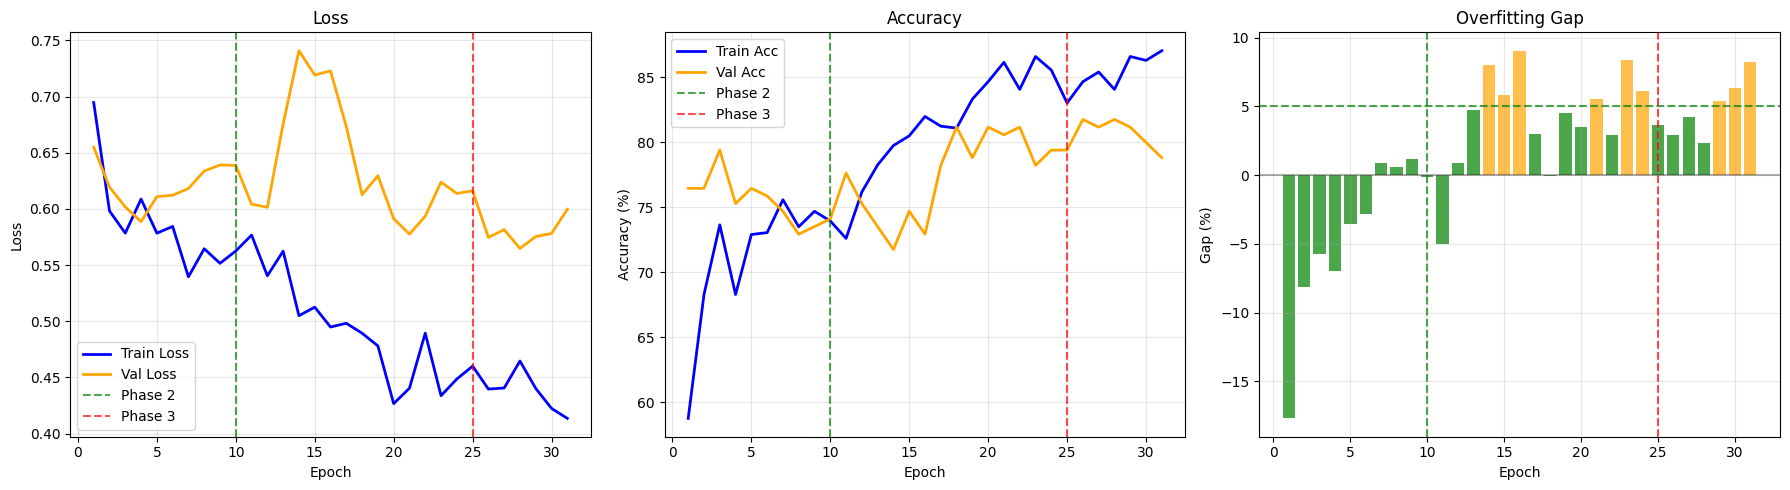

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
phase1_end = PHASE1_EPOCHS
phase2_end = PHASE1_EPOCHS + PHASE2_EPOCHS

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'orange', label='Val Loss', linewidth=2)
axes[0].axvline(x=phase1_end, color='green', linestyle='--', alpha=0.7, label='Phase 2')
axes[0].axvline(x=phase2_end, color='red', linestyle='--', alpha=0.7, label='Phase 3')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'orange', label='Val Acc', linewidth=2)
axes[1].axvline(x=phase1_end, color='green', linestyle='--', alpha=0.7, label='Phase 2')
axes[1].axvline(x=phase2_end, color='red', linestyle='--', alpha=0.7, label='Phase 3')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gap
gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['green' if g < 5 else 'orange' if g < 10 else 'red' for g in gap]
axes[2].bar(epochs_range, gap, color=colors, alpha=0.7)
axes[2].axhline(y=5, color='green', linestyle='--', alpha=0.7)
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2].axvline(x=phase1_end, color='green', linestyle='--', alpha=0.7)
axes[2].axvline(x=phase2_end, color='red', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Gap (%)')
axes[2].set_title('Overfitting Gap')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history_v4.png'), dpi=150)
plt.show()

---
# 🧪 Cell 11: TEST EVALUATION
---

In [ ]:
pip install sklearn

In [1]:
try:
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
except:
    !pip install scikit-learn seaborn
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns

# Load best model
checkpoint = torch.load(model_save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"📂 Loaded best model (Val Acc: {checkpoint['val_acc']:.2f}%)")
print(f"\n🧪 Testing on {len(test_dataset)} images...")

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_accuracy = 100 * np.mean(all_preds == all_labels)

print(f"\n{'='*60}")
print(f"🎯 TEST ACCURACY: {test_accuracy:.2f}%")
print(f"{'='*60}")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes, annot_kws={'size': 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Acc: {test_accuracy:.2f}%)')
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix_v4.png'), dpi=150)
plt.show()

ModuleNotFoundError: No module named 'sklearn'

---
# ✅ Cell 12: Final Summary
---

In [ ]:
print("\n" + "="*60)
print("🏆 V4 FINAL SUMMARY")
print("="*60)
print(f"\n   📊 Validation Accuracy: {best_accuracy:.2f}%")
print(f"   🧪 Test Accuracy:       {test_accuracy:.2f}%")
print(f"   📁 Model: classification_efficientnet_v4.pth")
print("="*60)

diff = abs(test_accuracy - best_accuracy)
if diff < 3:
    print("\n✅ Excellent generalization! Test ≈ Validation")
elif test_accuracy > best_accuracy:
    print("\n🎉 Great! Test > Validation")
else:
    print(f"\n⚠️ Test is {diff:.1f}% lower than validation")

---
# 🔮 Cell 13: Predict Single Image
---

In [ ]:
def predict_wound(image_path):
    """Predict wound infection status."""
    image = Image.open(image_path).convert('RGB')
    input_tensor = get_val_transforms()(image).unsqueeze(0).to(DEVICE)
    
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()
    
    class_names = ['infected', 'non-infected']
    prediction = class_names[pred_class]
    
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    color = 'red' if prediction == 'infected' else 'green'
    plt.title(f'{prediction.upper()} ({confidence*100:.1f}%)', fontsize=16, fontweight='bold', color=color)
    plt.axis('off')
    plt.show()
    
    return prediction, confidence

print("✅ Ready! Use: predict_wound(r'C:\\path\\to\\image.jpg')")